# NVFP4 GEMM Microbench Analysis — 2026-04-21 (Qwen3.5-27B-NVFP4)

In [1]:
import json, sys
from pathlib import Path
REPO = Path("/home/natfii/docker/nvllm")
sys.path.insert(0, str(REPO / "docs/research/gemm_sweep"))
import analyze
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV = REPO / "benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/microbench.csv"
OUT = REPO / "benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/shortlist.json"

df = analyze.load(CSV)
print(f"Loaded {len(df)} rows, {df['config_id'].nunique()} configs, {df['shape'].nunique()} shapes.")
df.head()


Loaded 840 rows, 21 configs, 4 shapes.


,config_id,shape,M,N,K,min_us,tm,tn,tk,sched,tsched
0,Cfg_128x128x128_Auto_Pers,qkv_proj,1,8192,5120,99.392,128,128,128,Auto,Pers
1,Cfg_128x128x128_TmaWSPing_Pers,qkv_proj,1,8192,5120,99.552,128,128,128,TmaWSPing,Pers
2,Cfg_128x128x128_TmaWSCoop_Pers,qkv_proj,1,8192,5120,99.296,128,128,128,TmaWSCoop,Pers
3,Cfg_128x128x128_TmaWSCoop_SK,qkv_proj,1,8192,5120,99.328,128,128,128,TmaWSCoop,SK
4,Cfg_128x128x256_Auto_Pers,qkv_proj,1,8192,5120,93.120,128,128,256,Auto,Pers


## Per-shape heatmap: configs (rows) × M (cols) → min μs

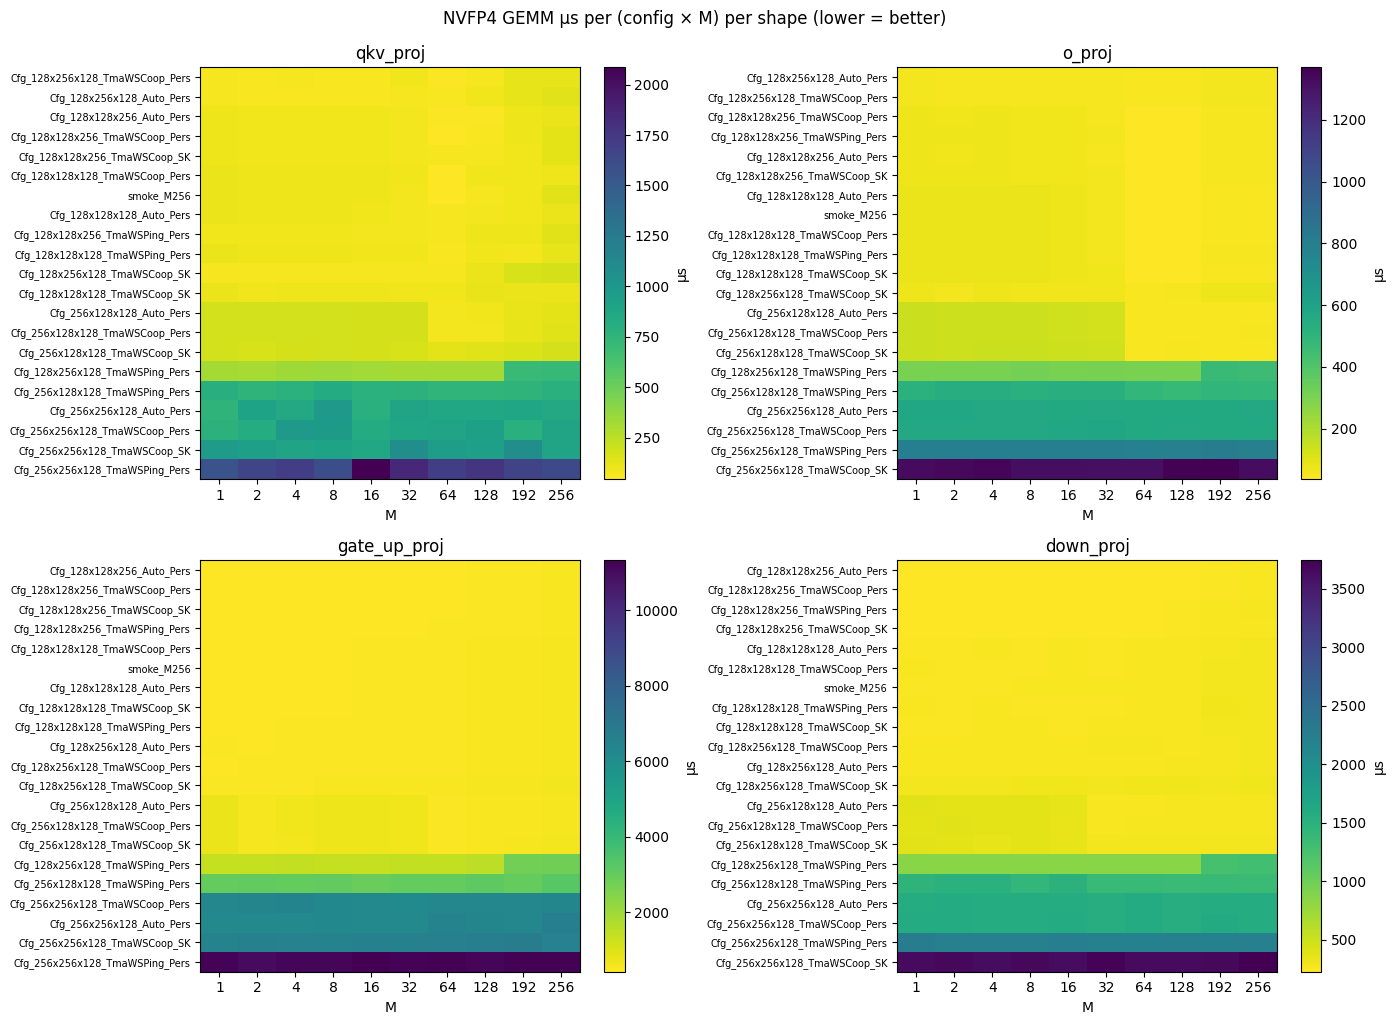

In [2]:
SHAPES = ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, shape in zip(axes.flat, SHAPES):
    sub = df[df["shape"] == shape].copy()
    piv = sub.pivot(index="config_id", columns="M", values="min_us")
    # Sort rows by total μs (ascending = best configs at top)
    piv = piv.loc[piv.sum(axis=1).sort_values().index]
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([i[:30] for i in piv.index], fontsize=7)
    ax.set_title(f"{shape}")
    ax.set_xlabel("M")
    fig.colorbar(im, ax=ax, label="μs")
plt.tight_layout()
plt.suptitle("NVFP4 GEMM μs per (config × M) per shape (lower = better)", y=1.02)
plt.show()


## Top-3 shortlist per (shape × M-bucket)

In [3]:
sl = analyze.shortlist_top3(df)
for shape, buckets in sl["by_shape"].items():
    print(f"\n{shape}:")
    for bucket, cfgs in sorted(buckets.items()):
        print(f"  {bucket}: {cfgs}")
print(f"\nTotal unique configs across all shortlists: {len(sl['all_configs'])}")



down_proj:
  1-8: ['Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSPing_Pers']
  16-32: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSPing_Pers', 'Cfg_128x128x256_TmaWSCoop_SK']
  192-256: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_TmaWSPing_Pers']
  64-128: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_TmaWSPing_Pers']

gate_up_proj:
  1-8: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_TmaWSCoop_SK']
  16-32: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_SK', 'Cfg_128x128x256_TmaWSCoop_Pers']
  192-256: ['Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_TmaWSCoop_SK']
  64-128: ['Cfg_128x128x256_TmaWSCoop_Pers', 'Cfg_128x128x256_Auto_Pers', 'Cfg_128x128x256_TmaWSCoop_SK']

o_proj:
  1-8: ['Cfg_128x256x128_TmaWSCoop_Pers', 'Cfg_128x256x128_Auto_Pers', 'Cfg_128x256x128_TmaWSCoop_SK']
  16-32: ['Cf

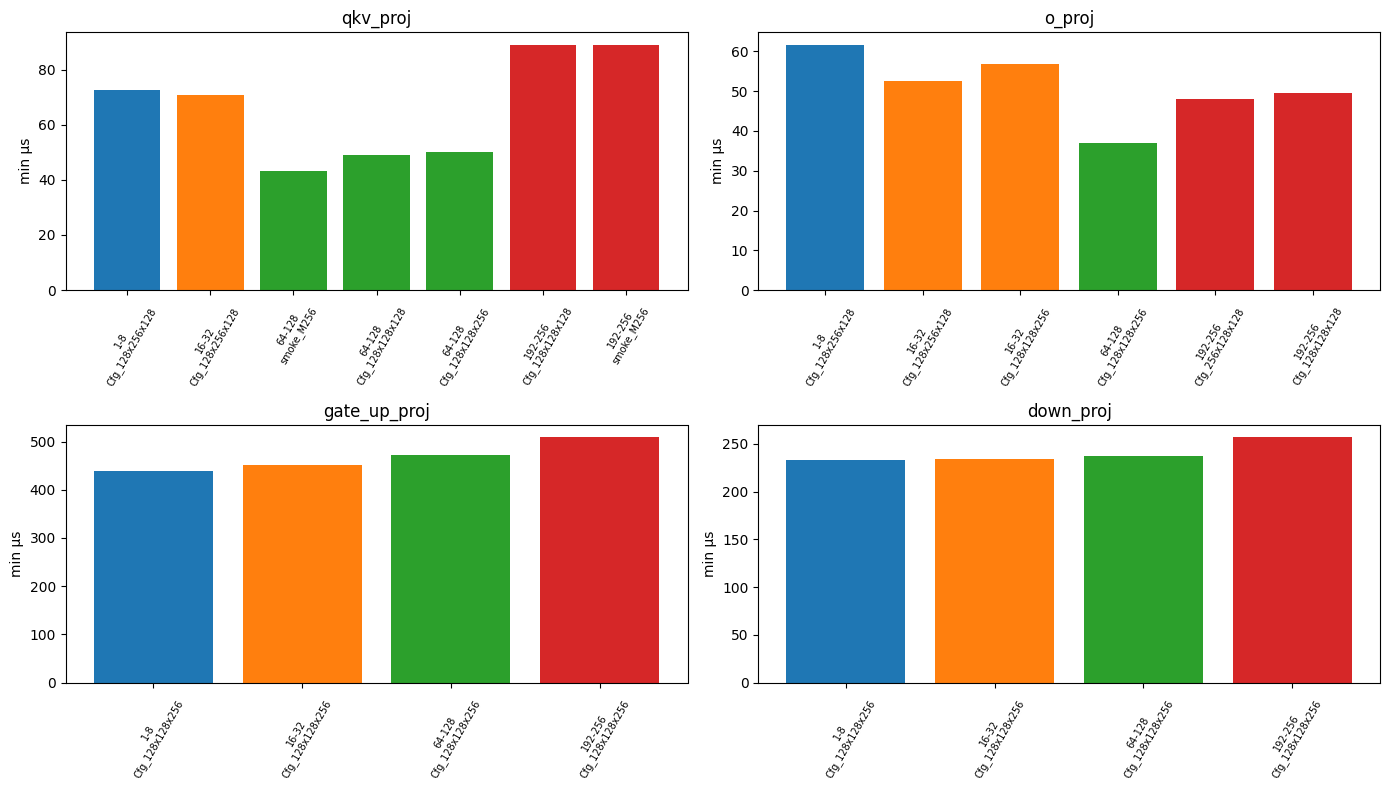

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, shape in zip(axes.flat, SHAPES):
    shape_data = []
    for bucket_name, (lo, hi) in analyze.M_BUCKETS:
        sub = df[(df["shape"] == shape) & (df["M"] >= lo) & (df["M"] <= hi)]
        top3 = sl["by_shape"].get(shape, {}).get(bucket_name, [])
        for cfg in top3:
            cfg_sub = sub[sub["config_id"] == cfg]
            if not cfg_sub.empty:
                shape_data.append({"bucket": bucket_name, "cfg": cfg, "us": cfg_sub["min_us"].min()})
    plot_df = pd.DataFrame(shape_data)
    if not plot_df.empty:
        for bucket in plot_df["bucket"].unique():
            sub = plot_df[plot_df["bucket"] == bucket]
            ax.bar([f"{bucket}\n{c[:15]}" for c in sub["cfg"]], sub["us"], label=bucket)
    ax.set_title(shape)
    ax.set_ylabel("min μs")
    ax.tick_params(axis="x", rotation=60, labelsize=7)
plt.tight_layout()
plt.show()


In [5]:
OUT.parent.mkdir(parents=True, exist_ok=True)
OUT.write_text(json.dumps(sl, indent=2))
print(f"Wrote {OUT}")


Wrote /home/natfii/docker/nvllm/benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/shortlist.json


## Handoff to B.2.2 / heuristic session
This dataset (microbench.csv + this notebook's rendered outputs + shortlist.json) is the input to a future session that builds the runtime dispatch table. Re-opening this notebook should reproduce the current analysis without re-running the sweep.